In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
#data_url = "https://raw.githubusercontent.com/dthonon/pna_loup_suivi/main/data/"
data_url = "/home/dthonon/Code/pna_loup_suivi/data/"

# Lecture des statistiques agricoles
cheptels = pd.read_excel(data_url + "SAA_2010-2024_définitives_donnees_departementales.xlsx", sheet_name="EFA", skiprows=5)
cheptels

,LIB_REG2,LIB_DEP,LIB_SAA,EFF_2010,EFF_2011,EFF_2012,EFF_2013,EFF_2014,EFF_2015,EFF_2016,EFF_2017,EFF_2018,EFF_2019,EFF_2020,EFF_2021,EFF_2022,EFF_2023,EFF_2024
0,11 - Île-de-France,077 - Seine-et-Marne,01 - Vaches laitières,4525,4434,4365,4296,4130,4092,3975,3906,3865,3752,3566,3423,3344,3296,3246
1,11 - Île-de-France,077 - Seine-et-Marne,02 - Vaches nourrices,3705,3570,3430,3538,3416,3464,3394,3273,3196,3040,2915,2908,2885,2773,2640
2,11 - Île-de-France,077 - Seine-et-Marne,03 - Toutes vaches (01 + 02),8230,8004,7795,7834,7546,7556,7369,7179,7061,6792,6481,6331,6229,6069,5886
3,11 - Île-de-France,077 - Seine-et-Marne,04 - Génisses laitières de renouvellement de p...,858,719,681,695,688,686,622,652,551,504,551,495,441,457,423
4,11 - Île-de-France,077 - Seine-et-Marne,05 - Génisses nourrices de renouvellement de p...,878,736,708,738,789,752,798,849,800,799,742,623,621,689,646
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495,976 - Mayotte,976 - Mayotte,31 - Agnelles,0,0,0,0,0,0,140,140,140,140,140,107,107,107,107
3496,976 - Mayotte,976 - Mayotte,32 - Brebis-mères (y compris de réforme),0,0,0,0,0,0,700,700,700,700,700,258,258,258,258
3497,976 - Mayotte,976 - Mayotte,33 - dont brebis-mères laitières,0,0,0,0,0,0,0,0,0,0,0,31,31,31,31
3498,976 - Mayotte,976 - Mayotte,34 - Autres ovins (y compris béliers),0,0,0,0,0,0,165,165,165,165,165,189,189,189,189


In [33]:
# Filtrer les données pour les ensembles d'espèces bovine, caprine et ovine
ensembles = ['20 - Ensemble espèce bovine (03 + 09 + 15 + 19)', '30 - Ensemble espèce caprine (27 + 28 + 29)', '35 - Ensemble espèce ovine (31 + 32 + 34)']
cheptel_sp = cheptels.query("LIB_SAA in @ensembles")
effectifs = ["EFF_2010", "EFF_2011", "EFF_2012", "EFF_2013", "EFF_2014", "EFF_2015", "EFF_2016", "EFF_2017", "EFF_2018", "EFF_2019", "EFF_2020", "EFF_2021", "EFF_2022", "EFF_2023", "EFF_2024"]
cheptel_sp[effectifs] = cheptel_sp[effectifs].div(cheptel_sp["EFF_2010"], axis=0) * 100
cheptel_sp_melted = cheptel_sp.melt(id_vars=["LIB_SAA", "LIB_DEP"], value_vars=effectifs, var_name="Année", value_name="Effectif")
cheptel_sp_melted["Année"] = cheptel_sp_melted["Année"].str.replace("EFF_", "").astype(int)
cheptel_sp_melted["Espèce"] = cheptel_sp_melted["LIB_SAA"].apply(lambda x : "Bovins" if "bovine" in x else ("Caprins" if "caprine" in x else "Ovins") )

In [34]:
cheptel_sp_melted

,LIB_SAA,LIB_DEP,Année,Effectif,Espèce
0,20 - Ensemble espèce bovine (03 + 09 + 15 + 19),077 - Seine-et-Marne,2010,100.000000,Bovins
1,30 - Ensemble espèce caprine (27 + 28 + 29),077 - Seine-et-Marne,2010,100.000000,Caprins
2,35 - Ensemble espèce ovine (31 + 32 + 34),077 - Seine-et-Marne,2010,100.000000,Ovins
3,20 - Ensemble espèce bovine (03 + 09 + 15 + 19),078 - Yvelines,2010,100.000000,Bovins
4,30 - Ensemble espèce caprine (27 + 28 + 29),078 - Yvelines,2010,100.000000,Caprins
...,...,...,...,...,...
4495,30 - Ensemble espèce caprine (27 + 28 + 29),974 - La Réunion,2024,76.492352,Caprins
4496,35 - Ensemble espèce ovine (31 + 32 + 34),974 - La Réunion,2024,133.479299,Ovins
4497,20 - Ensemble espèce bovine (03 + 09 + 15 + 19),976 - Mayotte,2024,inf,Bovins
4498,30 - Ensemble espèce caprine (27 + 28 + 29),976 - Mayotte,2024,inf,Caprins


In [19]:
# Apply the default theme
sns.set_theme()

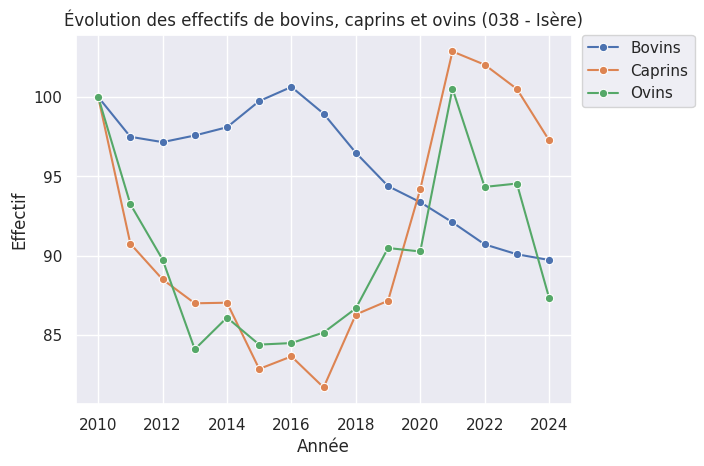

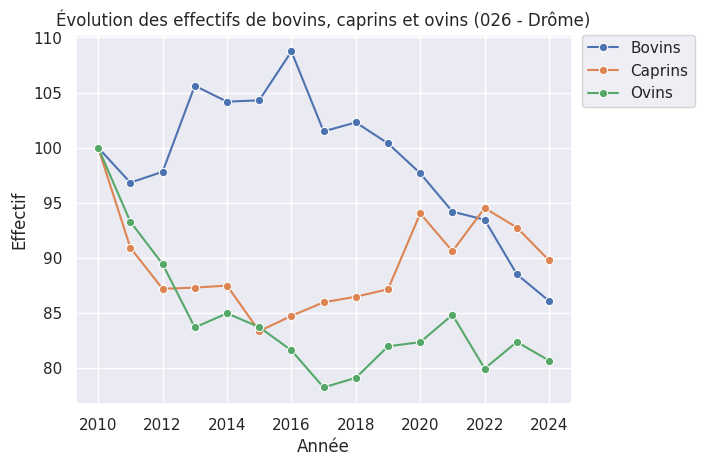

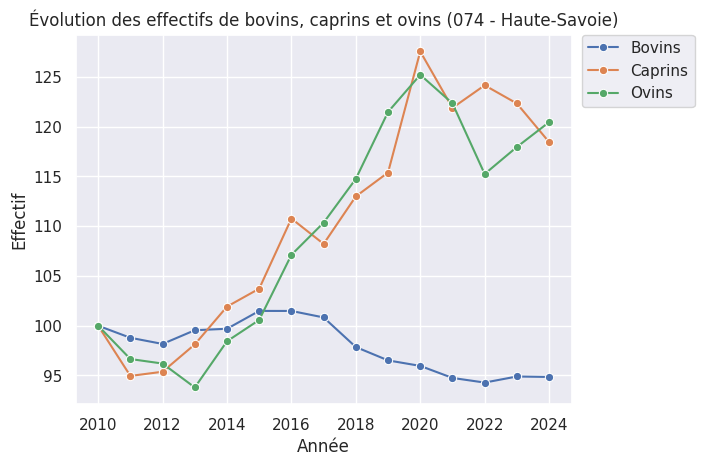

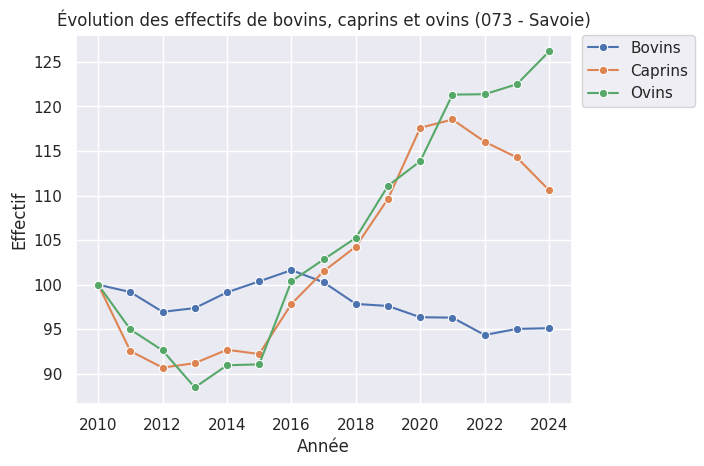

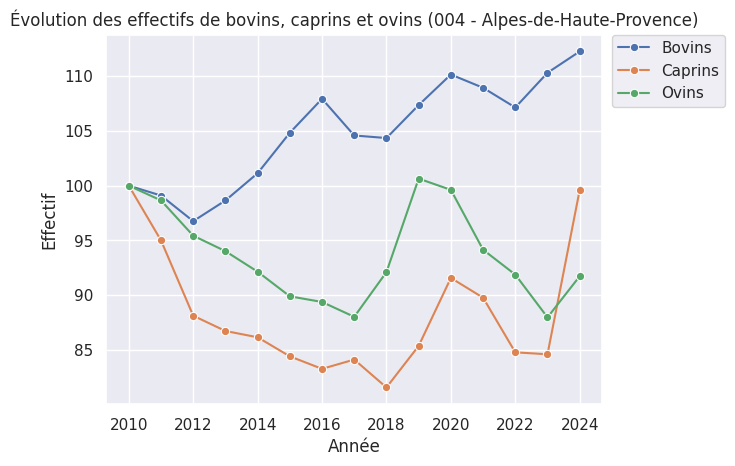

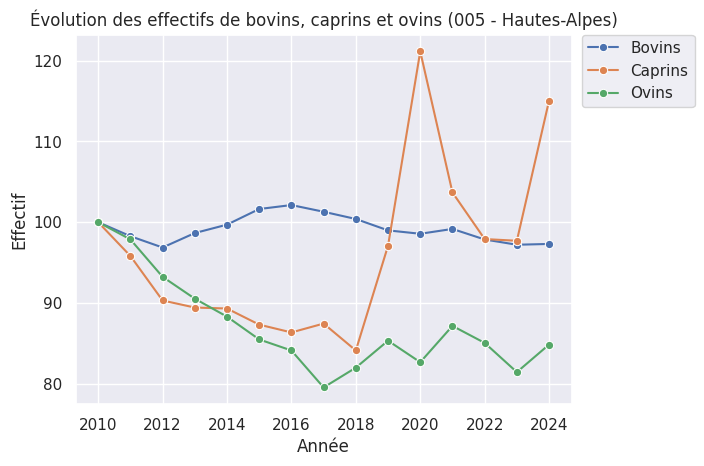

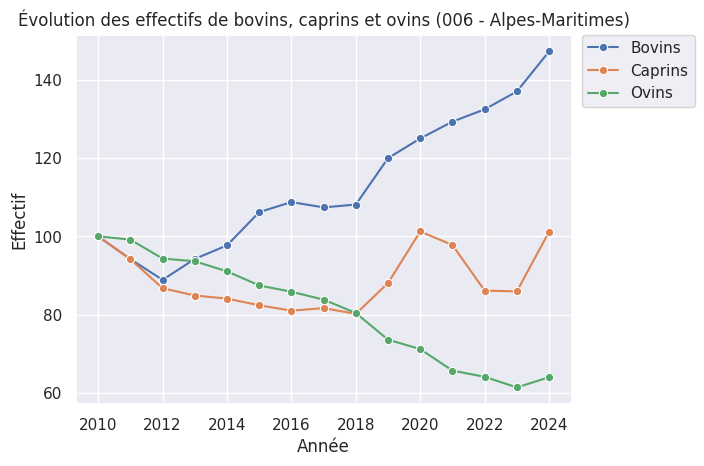

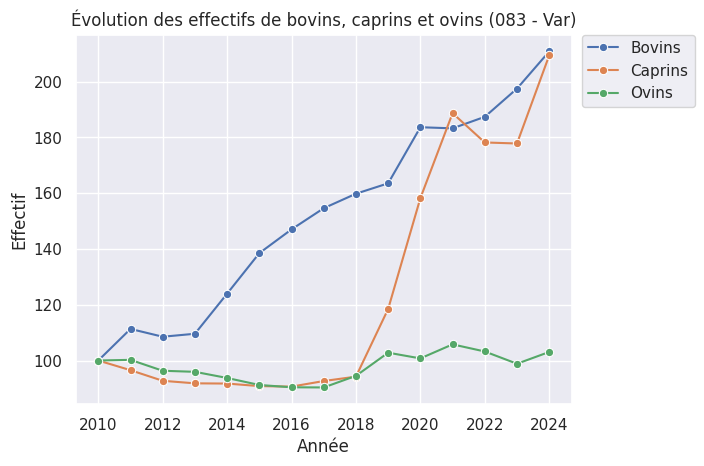

In [ ]:
dept = ["001 - Ain", "004 - Alpes-de-Haute-Provence", "005 - Hautes-Alpes", "006 - Alpes-Maritimes", "026 - Drôme", "038 - Isère", "073 - Savoie", "074 - Haute-Savoie", "083 - Var"]
for d in dept:
    filtered_data = cheptel_sp_melted[cheptel_sp_melted["LIB_DEP"] == d]
    sns.lineplot(data=filtered_data, x="Année", y="Effectif", hue="Espèce", marker="o").set(title=f"Évolution des effectifs de bovins, caprins et ovins ({d})");
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0);
    plt.show()